In [1]:
import sys 
sys.path.append('../')
import utils.utils as utils
import pandas as pd
import numpy as np
import json_loader.json_loader as json_loader
import plotly.express as px
import os
from datetime import date
from pandas.tseries.offsets import DateOffset
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
# import plotly.io as pio
# pio.renderers.default = "svg"

np.random.seed(42)


In [277]:
params = {  
            # kiexportált kérdőívek helye
            'excel_path': f'dataset/METSZI-Lavinia Exportok/kerdoivek/KiexportaltKerdoivek.xlsx',
            # eredmények helye
            'results_path': f'./results/v2stats/',

            # az adathalmaz kezdete 
            'start_year':2023, 
            'start_month':3,
            # az adathalmaz v;ge
            'end_year':2025,
            'end_month':8,       
            # az új vagy a régi adattal akarunk dolgozni
            'IS_NEWER_DATA':True,
            # a régi adatok helye
            'single_file_paths': {
                                'metszi_patients': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/Patients/Patients.json',
                                'lavinia_subjects': f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Subjects/Subjects.json',
                                'lavinia_sets':f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Sets/Sets.json',
                                'lavinia_foods':f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Foods/Foods.json'
                            },
            'drive_path':'dataset',
            'google_file_path':"195NKLh3YDojol3_s5t6nFL_cfyIw896-",

            # az adatok helye
            'folder_paths':{
                "metszi_appointments_folder": f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/Appointments/',
                'metszi_careplans_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/CarePlans/',
                'metszi_charts_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/ChartsResultTable/',
                'metszi_exercise_results_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/ExerciseResultTable/',
                'metszi_med_statements_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/MedicationStatements/',
                'metszi_observations_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/Observations/',
                'lavinia_observations_folder': f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Observations/'
            },
            # válaszd ki melyik adatot szeretnéd látni
            'load_appointments':False,
            'load_careplans':False,
            'load_charts':False,
            'load_exercise_results':True,
            'load_med_statements':True,
            'load_observations':True,
            'load_patients':False,
            'load_subjects':False,
            'load_weight_data':True,
            'load_set_data':False,
            'load_foods_data':False
         }

In [ ]:
# file-ok letöltése
# utils.download_and_extract_drive_zip(params['google_file_path'], output_dir=params['drive_path'])

Downloading...
From (original): https://drive.google.com/uc?id=195NKLh3YDojol3_s5t6nFL_cfyIw896-
From (redirected): https://drive.google.com/uc?id=195NKLh3YDojol3_s5t6nFL_cfyIw896-&confirm=t&uuid=d59de388-e95c-4aa8-90e5-61622c95780e
To: /Users/oliver/Documents/University/Uni_Projects/beteg_ut/betegut/research findings vol 2.0/dataset/temp_download.zip
100%|██████████| 146M/146M [00:02<00:00, 52.2MB/s] 


Sikeres kicsomagolás: dataset


In [ ]:
#Segítő függvények
def iqr_filter(df_data, col, tolerance = 1.5):
    """IQR szűrést végez a megadott oszlop adatain

    Args:
        df_data (pd.Data): Dataframe
        col (str): Szűrendő oszlop neve
        tolerance (number): Tolerancia mérőszám Defaults = 1.5
    Returns:
        df_iqr: IQR szűrt dataframe
    """

    df_cpy = df_data.copy()
    Q1 = df_cpy[col].quantile(0.25)
    Q3 = df_cpy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (tolerance * IQR)
    upper_bound = Q3 + (tolerance * IQR)
    df_iqr = df_cpy[(df_cpy[col] >= lower_bound) & (df_cpy[col] <= upper_bound)]
    return df_iqr

def weekly_aggregate(df_data, col_name):
    """Heti aggregáció

    Args:
        df_data (pd.Dataframe): Dataframe
        col_name (str): Kumulálandó oszlop neve
    Returns:
        df_data: heti aggregált dataframe
    """
    df_cpy = df_data.copy()
    df_cpy = iqr_filter(df_cpy, col_name)
    
    df_cpy['timestamp'] = pd.to_datetime(df_cpy['timestamp'].dt.date)
    df_cpy['week_ending'] = df_cpy['timestamp'].dt.to_period('W-Sat').apply(lambda r: r.end_time - pd.Timedelta(days=1))
    
    df_grouped = df_cpy.groupby(['patient_id', 'week_ending']).agg(
    mean = (col_name, 'mean'), 
    week_ending = ('week_ending', 'first')  #Az első érték megtartása
    )

    #Calculating the week index since first measurements
    df_grouped['week_index'] = df_grouped.groupby('patient_id')['week_ending'].transform(
        lambda x: ((x - x.min()).dt.days // 7)
    )

    return df_grouped.drop(columns = ['week_ending'])

def daily_aggregate(df_data, col_name):
    """Napi aggregáció elvégzése

    Args:
        df_data (pd.DataFrame): Dataframe
        col_name (str): Aggregálandó oszlop neve
    Returns:
        df_data: napi aggregált dataframe
    """
    df_cpy = df_data.copy()
    df_cpy = iqr_filter(df_cpy, col_name)
    df_cpy['timestamp'] = pd.to_datetime(df_cpy['timestamp'].dt.date)
    df_grouped = df_cpy.groupby(['patient_id', 'timestamp']).agg(
        mean = (col_name, 'mean'), 
        sum = (col_name, 'sum'),
        count = (col_name, 'count'),
        timestamp = ('timestamp', 'first')  #Az első érték megtartása
    )
    return df_grouped

In [303]:
# adtok betöltése
df_appointments, df_careplans, df_split_charts, df_exercise_results, df_med_statements, df_observations, df_patients, df_bs_measure, df_bp_measure, df_meal, df_comment, df_subjects, df_weight_measure, df_sets, df_foods = json_loader.load_v2_data(
                  params['single_file_paths'],
                  params['folder_paths'],
                  params['drive_path'],
                  params['start_year'],
                  params['start_month'],
                  params['end_year'],
                  params['end_month'],
                  params['IS_NEWER_DATA'],
                  load_appointments = params['load_appointments'],
                  load_careplans = params['load_careplans'],
                  load_charts = params['load_charts'],
                  load_exercise_results = params['load_exercise_results'],
                  load_med_statements = params['load_med_statements'],
                  load_observations = params['load_observations'],
                  load_patients=params['load_patients'],
                  load_subjects=params['load_subjects'],
                  load_weight_data=params['load_weight_data'],
                  load_sets = params['load_set_data'],
                  load_foods = params['load_foods_data']
                )

[LOAD] 2023-03 loaded!
[LOAD] 2023-04 loaded!
[LOAD] 2023-05 loaded!
[LOAD] 2023-06 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-07 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-08 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-09 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-10 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-11 loaded!
[LOAD] 2023-12 loaded!
[LOAD] 2024-01 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2024-02 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2024-03 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2024-04 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LO

In [193]:
#Heti aggregálás és szűrés 12 hétre
df_aggregated = weekly_aggregate(df_weight_measure, 'weight')
df_aggregated = df_aggregated.loc[df_aggregated['week_index'] <= 12].reset_index()
df_aggregated

,patient_id,week_ending,mean,week_index
0,652e5a721458e22775c958b9,2023-11-24 23:59:59.999999999,75.0,0
1,65c0c5e1ada973d9d6771259,2024-02-09 23:59:59.999999999,92.5,0
2,65eee0bf2c91f29df116c860,2024-03-15 23:59:59.999999999,93.0,0
3,65f840229c891cb6e9c5bc54,2024-03-22 23:59:59.999999999,175.8,0
4,65f840229c891cb6e9c5bc54,2024-06-14 23:59:59.999999999,164.7,12
...,...,...,...,...
1134,68ac245a625d5ebcee02a935,2025-08-29 23:59:59.999999999,94.1,0
1135,68ac25a40f2593ecbb3242e1,2025-08-29 23:59:59.999999999,99.2,0
1136,68ac338641f19957d9525075,2025-08-29 23:59:59.999999999,92.0,0
1137,68ac399e0b5f64e2a0c46e7f,2025-09-05 23:59:59.999999999,109.7,0


In [194]:
df_aggregated.patient_id.nunique()

257

In [195]:
#Violin plot a weight adatokhoz
fig = px.violin(df_aggregated, y="mean", box=True, points="all", hover_data=df_aggregated.columns, title="Mért súlyok eloszlása")
fig.update_yaxes(title_text='Heti átlagos súly (kg)')
fig.show()

Text(0, 0.5, 'Mérések száma')

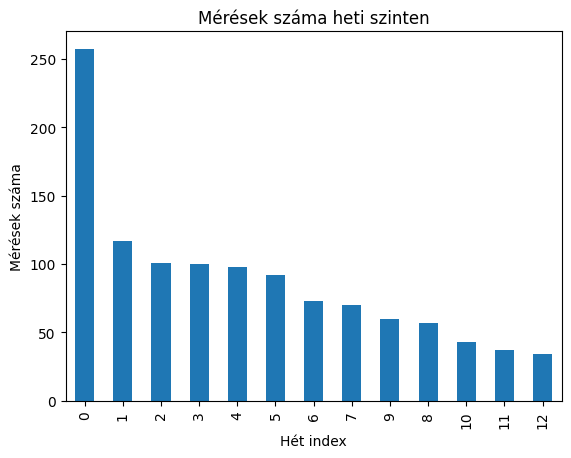

In [196]:
#Heti mérések hisztogrammja
df_aggregated['week_index'].value_counts().plot(kind='bar')
plt.title("Mérések száma heti szinten")
plt.xlabel("Hét index")
plt.ylabel("Mérések száma")

In [231]:
#Pivotálás, hogy a tanuló algoritmus megtudja enni.
df_pivot = pd.pivot(df_aggregated, index='patient_id', columns='week_index', values='mean')
# Filter patients who have at least one measurement after week 6
valid_patients = df_aggregated[df_aggregated['week_index'] > 6]['patient_id'].unique()
df_pivot = df_pivot[df_pivot.index.isin(valid_patients)]
df_pivot = df_pivot.ffill(axis=1)
df_pivot

week_index,0,1,2,3,4,5,6,7,8,9,10,11,12
patient_id,,,,,,,,,,,,,
65f840229c891cb6e9c5bc54,175.80,175.800000,175.800000,175.800000,175.8,175.80,175.80,175.80,175.80,175.80,175.80,175.80,164.70
65f841c6c1f10f80afcabc30,84.00,84.000000,84.000000,82.600000,82.6,81.55,81.55,79.80,77.80,77.40,76.40,76.50,76.80
66015f8a60dc394d21b4f57c,130.00,130.000000,130.000000,130.000000,130.0,130.00,127.00,127.00,126.00,126.00,126.00,126.00,126.00
660bd0f0fefe72528c1e85d5,110.60,109.766667,109.500000,109.500000,109.5,109.00,109.00,109.00,109.00,108.55,108.55,108.55,108.55
661e14934bb55b26195cc4ee,107.40,106.200000,106.400000,106.000000,105.5,104.10,103.90,104.40,103.60,102.90,103.20,102.20,102.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
686bb701932660905e3bcef3,108.00,108.000000,108.000000,108.000000,105.5,105.50,105.50,106.50,106.50,106.50,106.50,106.50,106.50
686bb86a021e0544acdc957b,115.00,113.800000,112.400000,113.650000,112.4,112.00,111.60,111.85,111.85,111.85,111.85,111.85,111.85
686bbf976b8245569456e5df,146.05,146.050000,144.000000,143.100000,142.2,141.30,141.30,140.50,140.50,140.50,140.50,140.50,140.50


In [232]:
#Mérések közötti külünbség számítása százalékban
df_diff = df_pivot.pct_change(axis=1)
df_diff = df_diff.drop(columns=[0], axis=1)
df_diff

week_index,1,2,3,4,5,6,7,8,9,10,11,12
patient_id,,,,,,,,,,,,
65f840229c891cb6e9c5bc54,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.063140
65f841c6c1f10f80afcabc30,0.000000,0.000000,-0.016667,0.000000,-0.012712,0.000000,-0.021459,-0.025063,-0.005141,-0.012920,0.001309,0.003922
66015f8a60dc394d21b4f57c,0.000000,0.000000,0.000000,0.000000,0.000000,-0.023077,0.000000,-0.007874,0.000000,0.000000,0.000000,0.000000
660bd0f0fefe72528c1e85d5,-0.007535,-0.002429,0.000000,0.000000,-0.004566,0.000000,0.000000,0.000000,-0.004128,0.000000,0.000000,0.000000
661e14934bb55b26195cc4ee,-0.011173,0.001883,-0.003759,-0.004717,-0.013270,-0.001921,0.004812,-0.007663,-0.006757,0.002915,-0.009690,-0.000978
...,...,...,...,...,...,...,...,...,...,...,...,...
686bb701932660905e3bcef3,0.000000,0.000000,0.000000,-0.023148,0.000000,0.000000,0.009479,0.000000,0.000000,0.000000,0.000000,0.000000
686bb86a021e0544acdc957b,-0.010435,-0.012302,0.011121,-0.010999,-0.003559,-0.003571,0.002240,0.000000,0.000000,0.000000,0.000000,0.000000
686bbf976b8245569456e5df,0.000000,-0.014036,-0.006250,-0.006289,-0.006329,0.000000,-0.005662,0.000000,0.000000,0.000000,0.000000,0.000000


In [233]:
df_diff.describe()

week_index,1,2,3,4,5,6,7,8,9,10,11,12
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,-0.005533,-0.004444,-0.005415,-0.005877,-0.002674,-0.003697,-0.003503,-0.003834,-0.003250,-0.001508,-0.001739,-0.002360
std,0.011016,0.009521,0.009915,0.013889,0.010562,0.008314,0.006873,0.008106,0.010949,0.004867,0.006188,0.007288
min,-0.045275,-0.035045,-0.063616,-0.079857,-0.040323,-0.030357,-0.033592,-0.050866,-0.071429,-0.019011,-0.029316,-0.063140
25%,-0.010463,-0.009936,-0.010528,-0.008949,-0.007517,-0.007372,-0.006963,-0.007152,-0.005489,-0.002081,-0.001003,-0.000781
50%,-0.000876,-0.002053,-0.001920,-0.003287,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.029719,0.033511,0.011121,0.034168,0.073094,0.023705,0.010112,0.011628,0.025000,0.012987,0.020600,0.004005


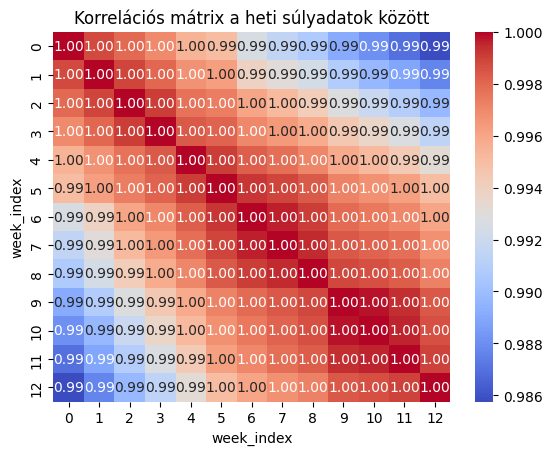

In [234]:
#Korrelációs mátrix elemzése
corr_matrix = df_pivot.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korrelációs mátrix a heti súlyadatok között")
plt.show()

In [235]:
#Klaszterezés eredeti dimenzióban, majd dimenziócsökkentés DBSCAN
dbscan = DBSCAN(eps=0.01, min_samples=2)
clusters = dbscan.fit_predict(df_diff)
df_re = df_diff.copy()
df_re['clusters_dbscan']  = clusters
#Klaszterek vizualizálása PCA-val
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_diff)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters
fig = px.scatter(df_pca, x='PC1', y='PC2', color='cluster', title='DBSCAN Klaszterek PCA-val csökkentett térben')
fig.show()

In [236]:
#Klaszterezés eredeti dimenzióban, majd dimenziócsökkentés Kmeans
kmeans = KMeans(n_clusters=2, max_iter=1000)
clusters = kmeans.fit_predict(df_diff)
df_re['clusters_kmeans'] = clusters
#Klaszterek vizualizálása PCA-val
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_diff)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters
fig = px.scatter(df_pca, x='PC1', y='PC2', color='cluster', title='Kmean Klaszterek PCA-val csökkentett térben')
fig.show()

## Klaszter magyarázat

In [237]:
df_meal_aggregated_daily = daily_aggregate(df_meal, '8')
df_meal_aggregated_daily['week_ending'] = df_meal_aggregated_daily['timestamp'].dt.to_period('W-Sat').apply(lambda r: r.end_time - pd.Timedelta(days=1))

df_meal_weekly = df_meal_aggregated_daily.groupby(['patient_id', 'week_ending']).agg(
calorie_sum = ('sum', 'sum'), 
obs_count = ('count', 'sum'),
week_ending = ('week_ending', 'first')  #Az első érték megtartása
)
df_meal_weekly['week_index'] = df_meal_weekly.groupby('patient_id')['week_ending'].transform(
    lambda x: ((x - x.min()).dt.days // 7)
)

df_meal_weekly = df_meal_weekly[['calorie_sum', 'obs_count', 'week_index']].reset_index()
df_meal_weekly = df_meal_weekly.loc[(df_meal_weekly['week_index'] <= 12 ) & (df_meal_weekly['patient_id'] != '-')].reset_index(drop=True)
df_meal_weekly

,patient_id,week_ending,calorie_sum,obs_count,week_index
0,652e5a721458e22775c958b9,2023-11-24 23:59:59.999999999,891.180000,5,0
1,652e5a721458e22775c958b9,2023-12-01 23:59:59.999999999,332.360000,2,1
2,655b4c264a1acf76108b4f9b,2024-06-28 23:59:59.999999999,3717.320000,41,0
3,655b4c264a1acf76108b4f9b,2024-07-05 23:59:59.999999999,3298.090000,33,1
4,655b4c264a1acf76108b4f9b,2024-07-12 23:59:59.999999999,2332.950000,23,2
...,...,...,...,...,...
3623,68ac399e0b5f64e2a0c46e7f,2025-09-05 23:59:59.999999999,791.650000,9,2
3624,68ac3b07a2abad579b24f0e6,2025-08-29 23:59:59.999999999,725.120000,5,0
3625,68ac3b07a2abad579b24f0e6,2025-09-05 23:59:59.999999999,785.320000,7,1
3626,68b5632f503b5b85915af10f,2023-11-17 23:59:59.999999999,768.623536,2,0


In [238]:
df_meal_pivot = pd.pivot(df_meal_weekly, index='patient_id', columns='week_index', values='calorie_sum')
df_meal_pivot

week_index,0,1,2,3,4,5,6,7,8,9,10,11,12
patient_id,,,,,,,,,,,,,
652e5a721458e22775c958b9,891.180000,332.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
655b4c264a1acf76108b4f9b,3717.320000,3298.090000,2332.950000,NaN,NaN,NaN,1374.520000,2709.330000,NaN,NaN,NaN,NaN,NaN
65c0c5e1ada973d9d6771259,1649.660338,6251.005508,5847.117876,4911.830764,4184.562312,5578.219507,1230.056368,NaN,NaN,NaN,NaN,198.324000,NaN
65c0c6a91a248de798c043dd,6565.917019,6993.158381,9393.378810,2432.904001,1590.331261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65c0c85b642be556102c59f9,893.565200,5935.467154,5409.841033,4828.207305,242.000000,1432.993000,5831.389247,4211.021271,6899.189771,3723.98943,4470.906722,2492.943052,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68ac31f0768e7fdc940b2c14,7692.320000,1763.190000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68ac338641f19957d9525075,2703.320000,8573.300000,829.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68ac399e0b5f64e2a0c46e7f,2779.750000,8552.290000,791.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [239]:
df_merged = pd.merge(df_re, df_meal_pivot, left_index=True, right_index=True, how='outer', suffixes=('_weight', '_calorie'))
df_merged.reset_index(inplace=True)
df_merged.to_excel("./temp/clustering.xlsx")
df_merged

week_index,patient_id,1_weight,2_weight,3_weight,4_weight,5_weight,6_weight,7_weight,8_weight,9_weight,...,3_calorie,4_calorie,5_calorie,6_calorie,7_calorie,8_calorie,9_calorie,10_calorie,11_calorie,12_calorie
0,652e5a721458e22775c958b9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,655b4c264a1acf76108b4f9b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1374.520000,2709.330000,NaN,NaN,NaN,NaN,NaN
2,65c0c5e1ada973d9d6771259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4911.830764,4184.562312,5578.219507,1230.056368,NaN,NaN,NaN,NaN,198.324000,NaN
3,65c0c6a91a248de798c043dd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2432.904001,1590.331261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65c0c85b642be556102c59f9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4828.207305,242.000000,1432.993000,5831.389247,4211.021271,6899.189771,3723.98943,4470.906722,2492.943052,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,68ac31f0768e7fdc940b2c14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
470,68ac338641f19957d9525075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471,68ac399e0b5f64e2a0c46e7f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
472,68ac3b07a2abad579b24f0e6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [370]:
#Készítsünk egy osszehasonlítást, ami megmutatja, hogy az első és a 12. hét között mennyi a súly eltérése százalékban és violin plot segítéségével ábrázoljuk klaszteronként
# Calculate the percentage change in weight
df_weight_comparison = df_pivot[[0, 12]].copy()
df_weight_comparison['weight_change'] = df_weight_comparison[12] - df_weight_comparison[0]
df_weight_comparison.reset_index(inplace=True)
df_weight_comparison.rename(columns={0: 'week_1_weight', 12: 'week_12_weight'}, inplace=True)

df_weight_comparison['weight_change_percent'] = (df_weight_comparison['weight_change'] / df_weight_comparison['week_1_weight']) * 100

# Add cluster information to the comparison dataframe
df_weight_comparison = pd.merge(df_weight_comparison, df_re[['clusters_kmeans']], left_on='patient_id', right_index=True, how='left')

# Create a violin plot to visualize the percentage weight change by clusters
fig = px.violin(df_weight_comparison, y="weight_change_percent", color="clusters_kmeans", box=True,
                hover_data=df_weight_comparison.columns, title="Súly változás (1 héttől a 12. hétig) Klaszterok szerint.")
fig.update_yaxes(title_text='Súly változás (%)')
fig.show()


In [356]:
#Melt, hogy könnyebben lehessen plottolni.
column_name = 'weight'
clustering = 'clusters_kmeans'
value_cols = [col for col in df_merged.columns if column_name in str(col)]
df_plot = df_merged.melt(id_vars=['patient_id', 'clusters_dbscan', 'clusters_kmeans'], value_vars=value_cols, var_name='week_index', value_name=column_name)
df_plot['week_index'] = df_plot['week_index'].str.extract('(\d+)').astype(float)
df_plot

,patient_id,clusters_dbscan,clusters_kmeans,week_index,weight
0,652e5a721458e22775c958b9,NaN,NaN,1.0,NaN
1,655b4c264a1acf76108b4f9b,NaN,NaN,1.0,NaN
2,65c0c5e1ada973d9d6771259,NaN,NaN,1.0,NaN
3,65c0c6a91a248de798c043dd,NaN,NaN,1.0,NaN
4,65c0c85b642be556102c59f9,NaN,NaN,1.0,NaN
...,...,...,...,...,...
5683,68ac31f0768e7fdc940b2c14,NaN,NaN,12.0,NaN
5684,68ac338641f19957d9525075,NaN,NaN,12.0,NaN
5685,68ac399e0b5f64e2a0c46e7f,NaN,NaN,12.0,NaN
5686,68ac3b07a2abad579b24f0e6,NaN,NaN,12.0,NaN


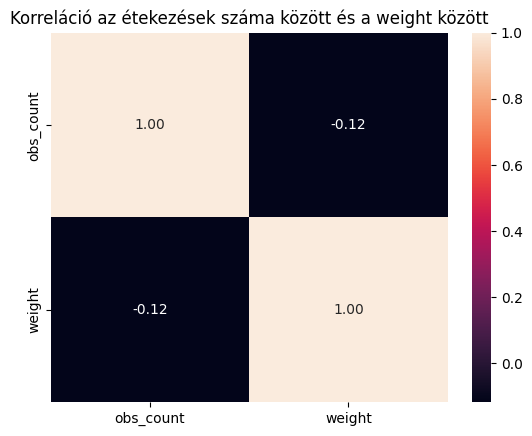

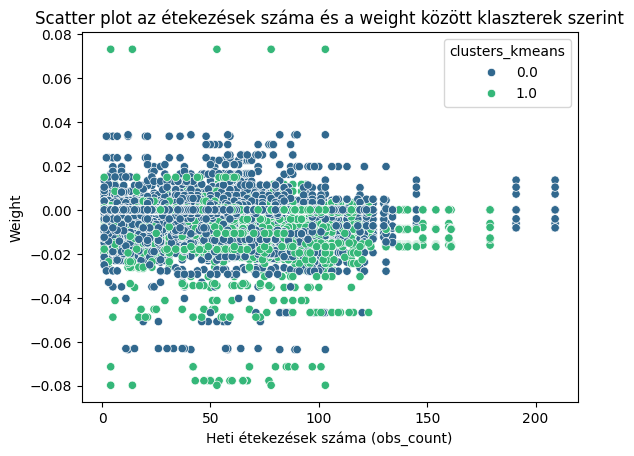

In [357]:
#Összefüggés a klaszter között és az étekézsek loggolása között
df_merged_obs_count = pd.merge(df_plot, df_meal_weekly, on = 'patient_id')
#Korreláció számítás a súly és az obs_count
df_corr = df_merged_obs_count[['obs_count', column_name]].corr()
sns.heatmap(df_corr, annot=True, fmt='.2f')
plt.title(f"Korreláció az étekezések száma között és a {column_name} között")
plt.show()

#Készítsünk egy scatter plottot, a column_name és obs_count kettő változó vizsgálata miatt
sns.scatterplot(data=df_merged_obs_count, x='obs_count', y=column_name, hue=clustering, palette='viridis')
plt.title(f"Scatter plot az étekezések száma és a {column_name} között klaszterek szerint")
plt.xlabel("Heti étekezések száma (obs_count)")
plt.ylabel(f"{column_name.capitalize()}")
plt.show()

In [358]:
df_merged_obs_count.groupby(clustering)[[column_name, 'obs_count']].describe()

weight                                                    \
                  count      mean       std       min       25%       50%   
clusters_kmeans                                                             
0.0              9108.0 -0.002580  0.007826 -0.063616 -0.005501  0.000000   
1.0              3120.0 -0.007133  0.011859 -0.079857 -0.011709 -0.004259   

                               obs_count                                   \
                 75%       max     count       mean       std  min    25%   
clusters_kmeans                                                             
0.0              0.0  0.034168    9108.0  48.171278  30.75841  1.0  24.00   
1.0              0.0  0.073094    3120.0  67.773077  34.44128  1.0  46.75   

                                     
                  50%    75%    max  
clusters_kmeans                      
0.0              46.0  67.00  209.0  
1.0              65.0  89.25  179.0

In [359]:
#Violin plot segítségével mutassuk meg az egyes klaszterok obs_count alakulásást plotlyval
fig = px.violin(df_merged_obs_count, y="obs_count", color=clustering, box=True, hover_data=df_merged_obs_count.columns, title="Étekezések száma klaszterek szerint")
fig.update_yaxes(title_text='Heti étekezések száma (obs_count)')
fig.show()

In [360]:
#A df_plot segítségével készítsünk egy ábrát, ami minden felhasználóra megmutatja a 12 héten keresztüli értékét és egy piros trend vonalat muatat, hogy a teljes adathalmazra mi volt az átlagos trend. Minden vonalat a neki megfelelő klaszter színnel színez.
fig = px.line(df_plot, x='week_index', y=column_name, color=clustering, line_group='patient_id', hover_data=['patient_id'], title=f'{column_name}változás a 12 hét alatt klaszterek szerint')
# Calculate the average trend line
avg_trend = df_plot.groupby('week_index')[column_name].mean().reset_index()

# Add the average trend line to the figure
fig.add_scatter(x=avg_trend['week_index'], y=avg_trend[column_name], mode='lines', line=dict(color='red', dash='dash'), name='Average Trend')
fig.show()

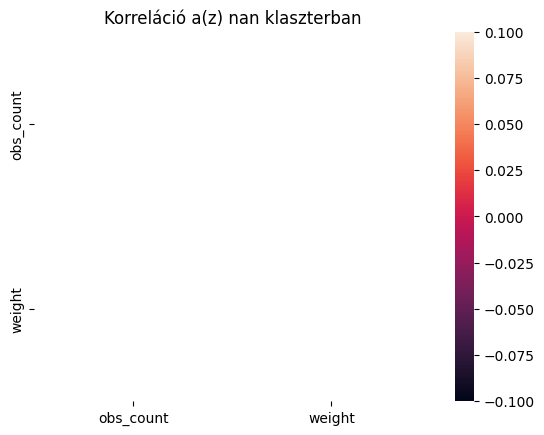

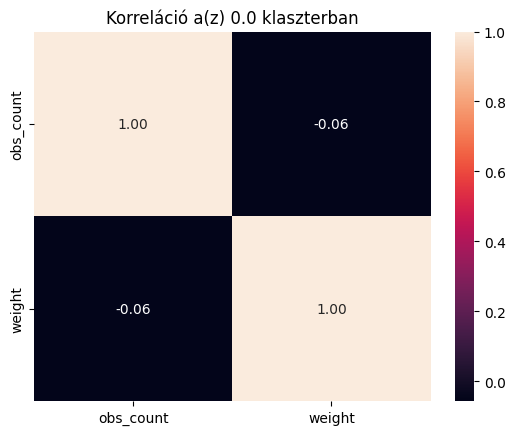

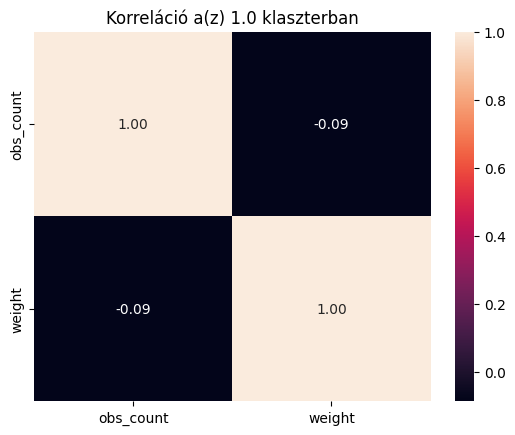

In [361]:
#Korreláció a klasztereknél az obs_count és column_name között
for cluster in df_merged_obs_count[clustering].unique():
    df_tmp = df_merged_obs_count.loc[df_merged_obs_count[clustering] == cluster, ['obs_count', column_name]].corr()
    sns.heatmap(df_tmp, fmt = '.2f', annot=True)
    plt.title(f"Korreláció a(z) {cluster} klaszterban")
    plt.show()

In [362]:
#A df_plot segítségével készítsünk egy ábrát, ami minden felhasználóra megmutatja a 12 héten keresztüli értékét és egy piros trend vonalat muatat, hogy a teljes adathalmazra mi volt az átlagos trend. Minden vonalat a neki megfelelő klaszter színnel színez.
fig = px.line(df_plot, x='week_index', y=column_name, color=clustering, line_group='patient_id', hover_data=['patient_id'], title=f'{column_name} változás a 12 hét alatt klaszterek szerint')
# Calculate the average trend line
avg_trend = df_plot.groupby('week_index')[column_name].mean().reset_index()

# Add the average trend line to the figure
fig.add_scatter(x=avg_trend['week_index'], y=avg_trend[column_name], mode='lines', line=dict(color='red', dash='dash'), name='Average Trend')
fig.show()

### Exercise resultsal való magyarázat

In [363]:
df_exercise_results.rename(columns={'ert_end_date': 'timestamp'}, inplace=True)
df_exercise_results['timestamp'] = pd.to_datetime(df_exercise_results['timestamp'])
df_exercise_results

,ert_row_id,ert_start_date,timestamp,ert_result_table_type,patient_id,ert_exercise_base_training_type,ert_exercise_base_steps_value,ert_exercise_base_steps_value_unit,ert_exercise_base_activity_time,ert_exercise_base_activity_time_unit,ert_exercise_base_burnt_calorie,ert_exercise_base_burnt_calorie_unit,ert_exercise_extra
0,YeTqD93a6FTHvV5NRO3I,2024-04-05T00:00:00.000Z,2024-04-05 23:59:59+00:00,daily,65d32a1137a2ee5d0941de26,ACTIVITY,0,steps,24,hour,0,kcal,[]
1,xTxgQJRFRSv5HlCss33k,2024-04-04T00:00:00.000Z,2024-04-04 23:59:59+00:00,daily,65d32a1137a2ee5d0941de26,ACTIVITY,21048,steps,24,hour,2082,kcal,[]
2,yoV6ejQjRiGcyWdsngOn,2024-04-06T00:00:00.000Z,2024-04-06 23:59:59+00:00,daily,65d32a1137a2ee5d0941de26,ACTIVITY,16377,steps,24,hour,1859,kcal,[]
3,rSCon8ZWo1OLHFYwPf9j,2024-01-01T00:00:00.000Z,2024-01-01 23:59:59+00:00,daily,6576e277558270d28c67320c,ACTIVITY,2040,steps,24,hour,200,kcal,"[{'trainingType': 'RUNNING', 'verylightPulseIn..."
4,lvJ7lehTcTjuRlyaiwAl,2024-01-02T00:00:00.000Z,2024-01-02 23:59:59+00:00,daily,6576e277558270d28c67320c,ACTIVITY,3419,steps,24,hour,440,kcal,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28579,teiT3xi7izcxbUajKFTf,2025-08-31T00:00:00.000Z,2025-08-31 23:59:59+00:00,daily,68ac338641f19957d9525075,ACTIVITY,0,steps,24,hour,0,kcal,"[{'trainingType': 'CYCLING', 'trainingTime': 3..."
28580,4gqUWSDWH3fksxKuthfx,2025-08-31T00:00:00.000Z,2025-08-31 23:59:59+00:00,daily,684fede8e322332cfa0e3528,ACTIVITY,0,steps,24,hour,0,kcal,"[{'trainingType': 'STAIR_WORKOUT', 'trainingTi..."
28581,joi8GRumPHWK9kIrxpxS,2025-08-30T00:00:00.000Z,2025-08-30 23:59:59.999000+00:00,daily,68ac338641f19957d9525075,ACTIVITY,0,steps,24,hour,0,kcal,"[{'trainingType': 'Kerékpározás', 'trainingTim..."
28582,r1CVBuBKjOaSmlY4C17f,2025-08-31T00:00:00.000Z,2025-08-31 23:59:59.999000+00:00,daily,68ac399e0b5f64e2a0c46e7f,ACTIVITY,0,steps,24,hour,0,kcal,"[{'trainingType': 'Kerékpározás', 'trainingTim..."


In [364]:
df_exercise_weekly = weekly_aggregate(df_exercise_results, 'ert_exercise_base_burnt_calorie')
df_exercise_weekly.reset_index(inplace=True)

In [365]:
df_merged_exerices = pd.merge(df_exercise_weekly, df_merged_obs_count, how = 'outer')
df_merged_exerices

,patient_id,week_ending,mean,week_index,clusters_dbscan,clusters_kmeans,week_index_x,weight,calorie_sum,obs_count,week_index_y
0,6422b870b353429c9c41585c,2023-03-31 23:59:59.999999999,1262.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6422b870b353429c9c41585c,2023-04-07 23:59:59.999999999,1308.571429,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6422b870b353429c9c41585c,2023-04-14 23:59:59.999999999,1276.857143,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6422b870b353429c9c41585c,2023-04-21 23:59:59.999999999,1582.714286,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6422b870b353429c9c41585c,2023-04-28 23:59:59.999999999,1724.714286,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
46950,68b5632f503b5b85915af10f,2023-11-24 23:59:59.999999999,NaN,NaN,NaN,NaN,8.0,NaN,1.0,1.0,1.0
46951,68b5632f503b5b85915af10f,2023-11-24 23:59:59.999999999,NaN,NaN,NaN,NaN,9.0,NaN,1.0,1.0,1.0
46952,68b5632f503b5b85915af10f,2023-11-24 23:59:59.999999999,NaN,NaN,NaN,NaN,10.0,NaN,1.0,1.0,1.0
46953,68b5632f503b5b85915af10f,2023-11-24 23:59:59.999999999,NaN,NaN,NaN,NaN,11.0,NaN,1.0,1.0,1.0


In [366]:
df_merged_exerices.dropna(subset=['clusters_kmeans', 'mean'], inplace=True)
df_merged_exerices.rename(columns={'mean': 'weekly_calorie_burn'}, inplace=True)
df_merged_exerices

,patient_id,week_ending,weekly_calorie_burn,week_index,clusters_dbscan,clusters_kmeans,week_index_x,weight,calorie_sum,obs_count,week_index_y
2718,65f841c6c1f10f80afcabc30,2024-03-22 23:59:59.999999999,0.000000,0.0,-1.0,0.0,1.0,0.000000,2452.101407,22.0,0.0
2719,65f841c6c1f10f80afcabc30,2024-03-22 23:59:59.999999999,0.000000,0.0,-1.0,0.0,2.0,0.000000,2452.101407,22.0,0.0
2720,65f841c6c1f10f80afcabc30,2024-03-22 23:59:59.999999999,0.000000,0.0,-1.0,0.0,3.0,-0.016667,2452.101407,22.0,0.0
2721,65f841c6c1f10f80afcabc30,2024-03-22 23:59:59.999999999,0.000000,0.0,-1.0,0.0,4.0,0.000000,2452.101407,22.0,0.0
2722,65f841c6c1f10f80afcabc30,2024-03-22 23:59:59.999999999,0.000000,0.0,-1.0,0.0,5.0,-0.012712,2452.101407,22.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
44978,6874e32f86ec4f1871f75d97,2025-08-15 23:59:59.999999999,1226.857143,4.0,-1.0,1.0,8.0,0.000000,5870.970000,96.0,4.0
44979,6874e32f86ec4f1871f75d97,2025-08-15 23:59:59.999999999,1226.857143,4.0,-1.0,1.0,9.0,0.000000,5870.970000,96.0,4.0
44980,6874e32f86ec4f1871f75d97,2025-08-15 23:59:59.999999999,1226.857143,4.0,-1.0,1.0,10.0,0.000000,5870.970000,96.0,4.0
44981,6874e32f86ec4f1871f75d97,2025-08-15 23:59:59.999999999,1226.857143,4.0,-1.0,1.0,11.0,0.000000,5870.970000,96.0,4.0


In [372]:
#Violin plot segítségével mutassuk meg, hogy az egyes klaszterokban hogyan alakul a weekly_calori_burn
fig = px.violin(df_merged_exerices, y="obs_count", color=clustering, box=True, hover_data=df_merged_exerices.columns, title="Heti edzés szám klaszterek szerint")
fig.update_yaxes(title_text='Heti edzés szám')
fig.show()

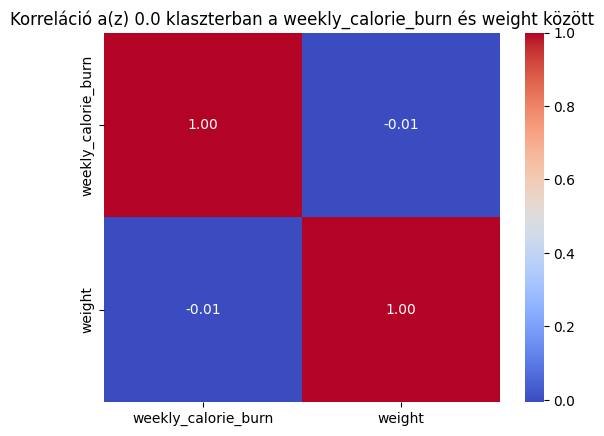

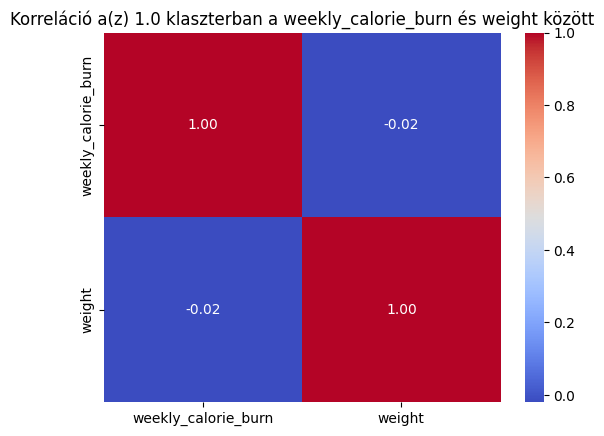

In [368]:
#Készítsünk korrelációs ábrát a weekly_calorie_burn és a weight oszlop között klaszterenként
for cluster in df_merged_exerices[clustering].unique():
    cluster_data = df_merged_exerices[df_merged_exerices[clustering] == cluster]
    corr = cluster_data[['weekly_calorie_burn', column_name]].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title(f"Korreláció a(z) {cluster} klaszterban a weekly_calorie_burn és weight között")
    plt.show()

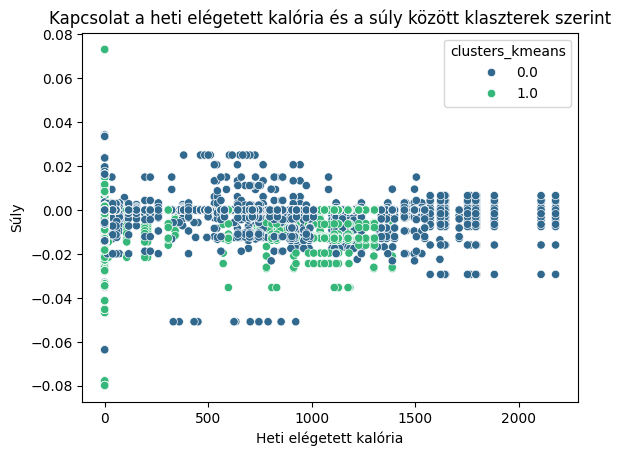

In [369]:
#SCatter plot segítségével mutassuk meg a weekly_calorie_burn és weigth közötti kapcsolatot.
sns.scatterplot(data=df_merged_exerices, x='weekly_calorie_burn', y=column_name, hue=clustering, palette='viridis')
plt.title("Kapcsolat a heti elégetett kalória és a súly között klaszterek szerint")
plt.xlabel("Heti elégetett kalória")
plt.ylabel("Súly")
plt.show()